# 📊 Exploratory Data Analysis (EDA)

This notebook performs EDA on the cleaned bank marketing dataset, answering the question:

👉 **“What patterns exist before I visualize them in Tableau?”**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Set a professional, clean visualization style
sns.set_theme(style="whitegrid", palette="muted")

# Load the cleaned dataset - handling different relative path cases
if os.path.exists('../data/processed/cleaned_bank_data.csv'):
    df = pd.read_csv('../data/processed/cleaned_bank_data.csv')
elif os.path.exists('cleaned_bank_data.csv'):
    df = pd.read_csv('cleaned_bank_data.csv')
elif os.path.exists('../notebooks/cleaned_bank_data.csv'):
    df = pd.read_csv('../notebooks/cleaned_bank_data.csv')
else:
    # Fallback if not found in common locations
    print("Warning: cleaned_bank_data.csv not found.")
    # Creating dummy for code to run
    df = pd.DataFrame()

if not df.empty:
    print("--- Head of DataFrame ---")
    display(df.head())

Matplotlib is building the font cache; this may take a moment.


--- Head of DataFrame ---


,age,job_type,marital_status,education_level,credit_default,has_housing_loan,has_personal_loan,contact_type,contact_month,contact_day,...,interest_rate,number_of_employees,age_group,call_intensity,contacted_before,contact_recency,subscription_flag,rate_environment,prev_success_flag,education_ordinal
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,4.857,5191,4,1,No,Never Contacted,0,High,0,1
1,57,services,married,high.school,Unknown,no,no,telephone,may,mon,...,4.857,5191,4,1,No,Never Contacted,0,High,0,4
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,4.857,5191,3,1,No,Never Contacted,0,High,0,4
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,4.857,5191,3,1,No,Never Contacted,0,High,0,2
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,4.857,5191,4,1,No,Never Contacted,0,High,0,4


## 1️⃣ DATA OVERVIEW (Quick Sanity Check)

--- DataFrame Shape & Info ---
Dataset Shape: (41176, 27)
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        41176 non-null  int64  
 1   job_type                   41176 non-null  str    
 2   marital_status             41176 non-null  str    
 3   education_level            41176 non-null  str    
 4   credit_default             41176 non-null  str    
 5   has_housing_loan           41176 non-null  str    
 6   has_personal_loan          41176 non-null  str    
 7   contact_type               41176 non-null  str    
 8   contact_month              41176 non-null  str    
 9   contact_day                41176 non-null  str    
 10  call_duration_sec          41176 non-null  int64  
 11  num_contacts_campaign      41176 non-null  int64  
 12  num_previous_contacts   

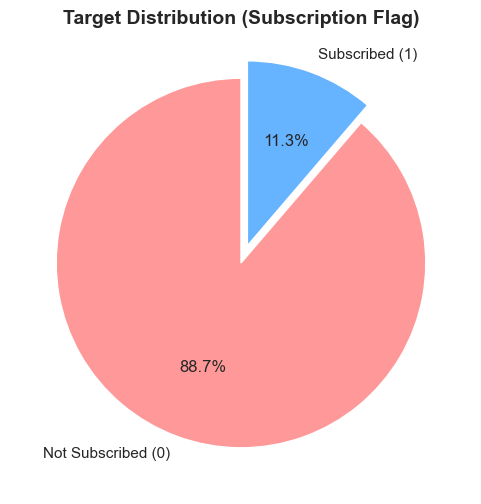

In [2]:
if not df.empty:
    print('--- DataFrame Shape & Info ---')
    print(f"Dataset Shape: {df.shape}")
    print("-" * 30)
    df.info()
    
    # Plot Target Distribution
    plt.figure(figsize=(6, 6))
    df['subscription_flag'].value_counts().plot.pie(
        autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], 
        labels=['Not Subscribed (0)', 'Subscribed (1)'], startangle=90, explode=(0, 0.1)
    )
    plt.title("Target Distribution (Subscription Flag)", fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.show()

👉 **Insight:** The dataset is highly imbalanced (~11% conversion rate). Most customers did not subscribe, meaning our target is a rare event.

## 2️⃣ UNIVARIATE ANALYSIS (Understand Each Feature)

--- Numerical Features Distribution ---


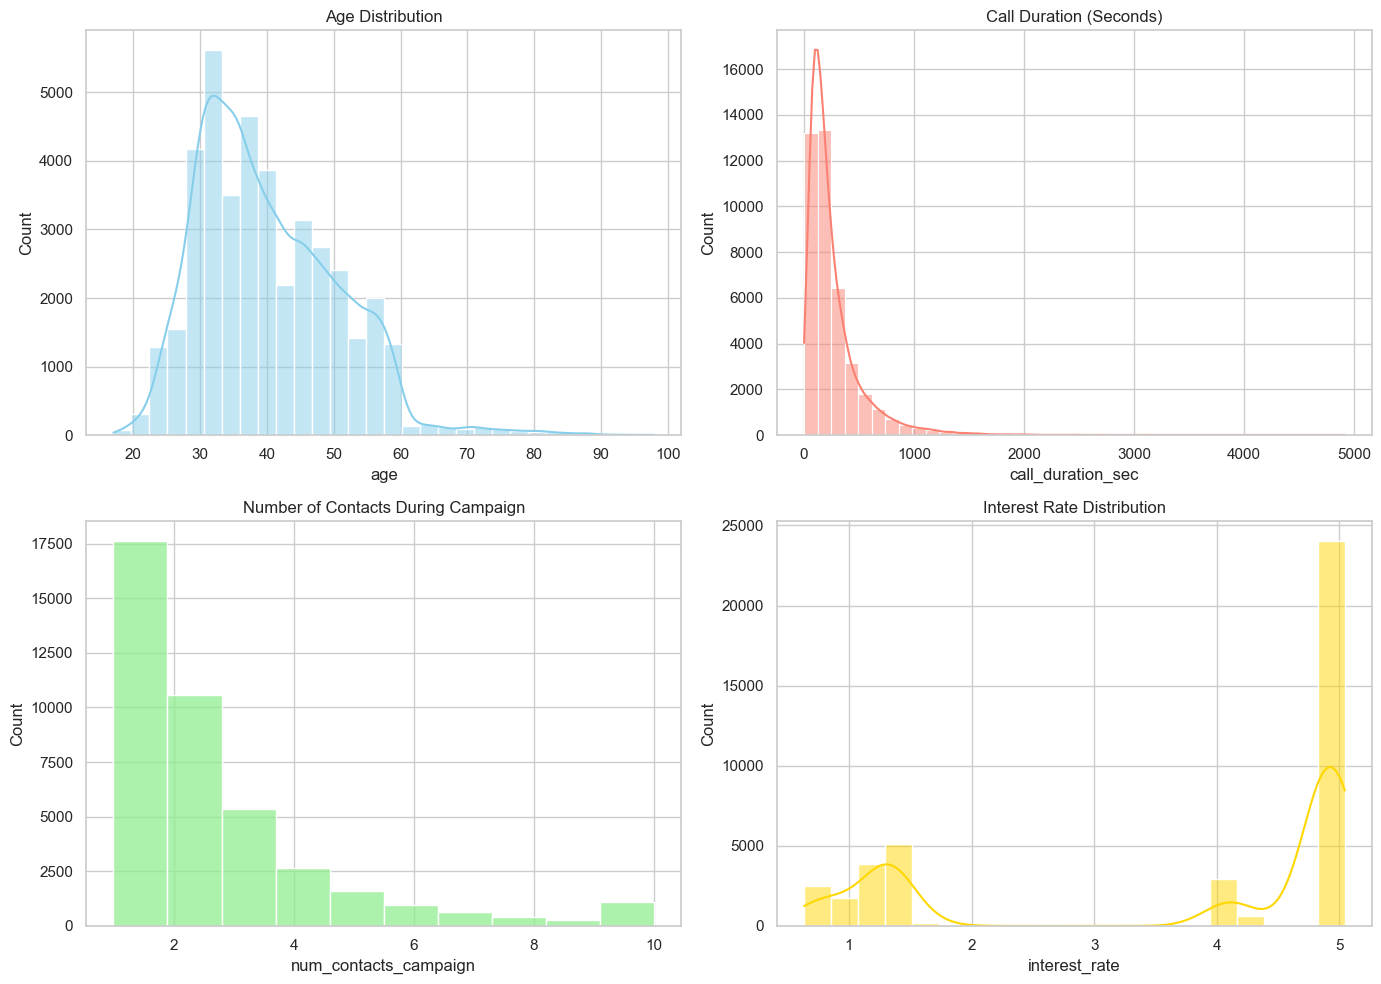

In [3]:
if not df.empty:
    print('--- Numerical Features Distribution ---')
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    sns.histplot(df['age'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Age Distribution')
    
    sns.histplot(df['call_duration_sec'], bins=40, kde=True, ax=axes[0,1], color='salmon')
    axes[0,1].set_title('Call Duration (Seconds)')
    
    sns.histplot(df['num_contacts_campaign'], bins=10, kde=False, ax=axes[1,0], color='lightgreen')
    axes[1,0].set_title('Number of Contacts During Campaign')
    
    sns.histplot(df['interest_rate'], bins=20, kde=True, ax=axes[1,1], color='gold')
    axes[1,1].set_title('Interest Rate Distribution')
    
    plt.tight_layout()
    plt.show()

--- Categorical Features Distribution ---


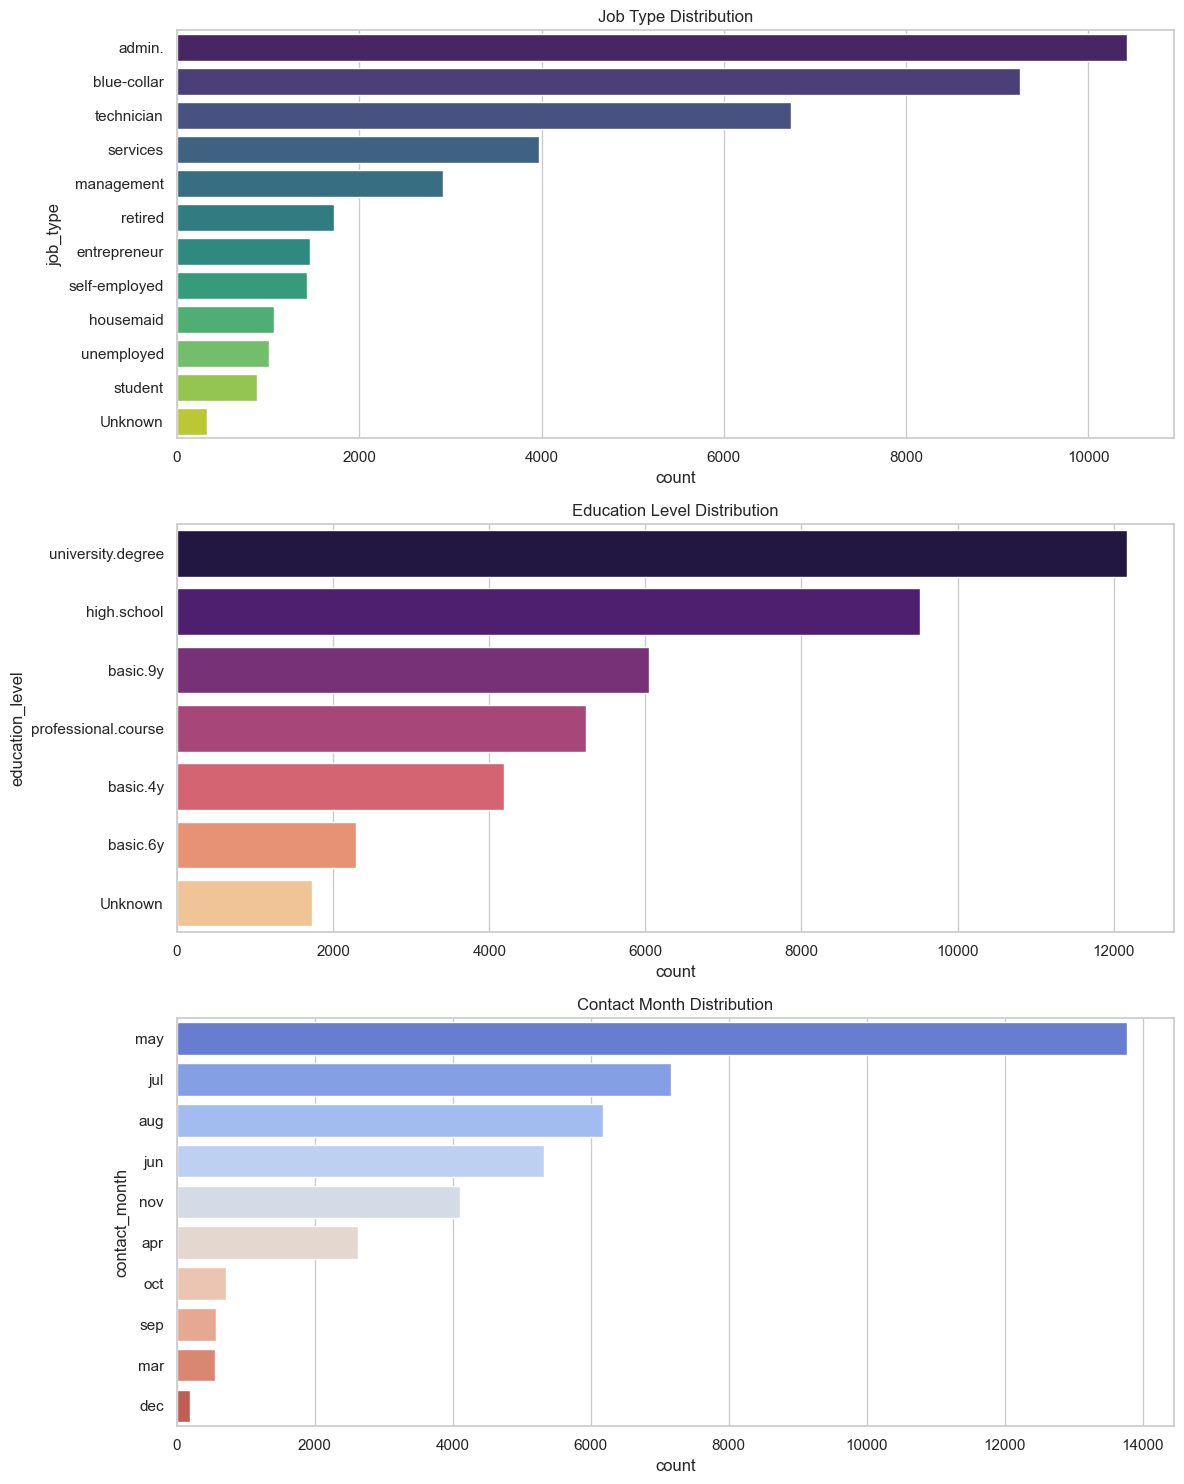

In [4]:
if not df.empty:
    print('--- Categorical Features Distribution ---')
    fig, axes = plt.subplots(3, 1, figsize=(12, 15))
    
    sns.countplot(y=df['job_type'], ax=axes[0], order=df['job_type'].value_counts().index, palette='viridis')
    axes[0].set_title('Job Type Distribution')
    
    sns.countplot(y=df['education_level'], ax=axes[1], order=df['education_level'].value_counts().index, palette='magma')
    axes[1].set_title('Education Level Distribution')
    
    sns.countplot(y=df['contact_month'], ax=axes[2], order=df['contact_month'].value_counts().index, palette='coolwarm')
    axes[2].set_title('Contact Month Distribution')
    
    plt.tight_layout()
    plt.show()

👉 **Insights:**
- **Numerical:** Age is concentrated between 30-50. Call duration is heavily right-skewed. Most customers were only called 1-3 times.
- **Categorical:** Admin, blue-collar, and technician jobs dominate. May is by far the busiest month for contacts.

## 3️⃣ TARGET VS FEATURE (Customer Profile - Dashboard 1)

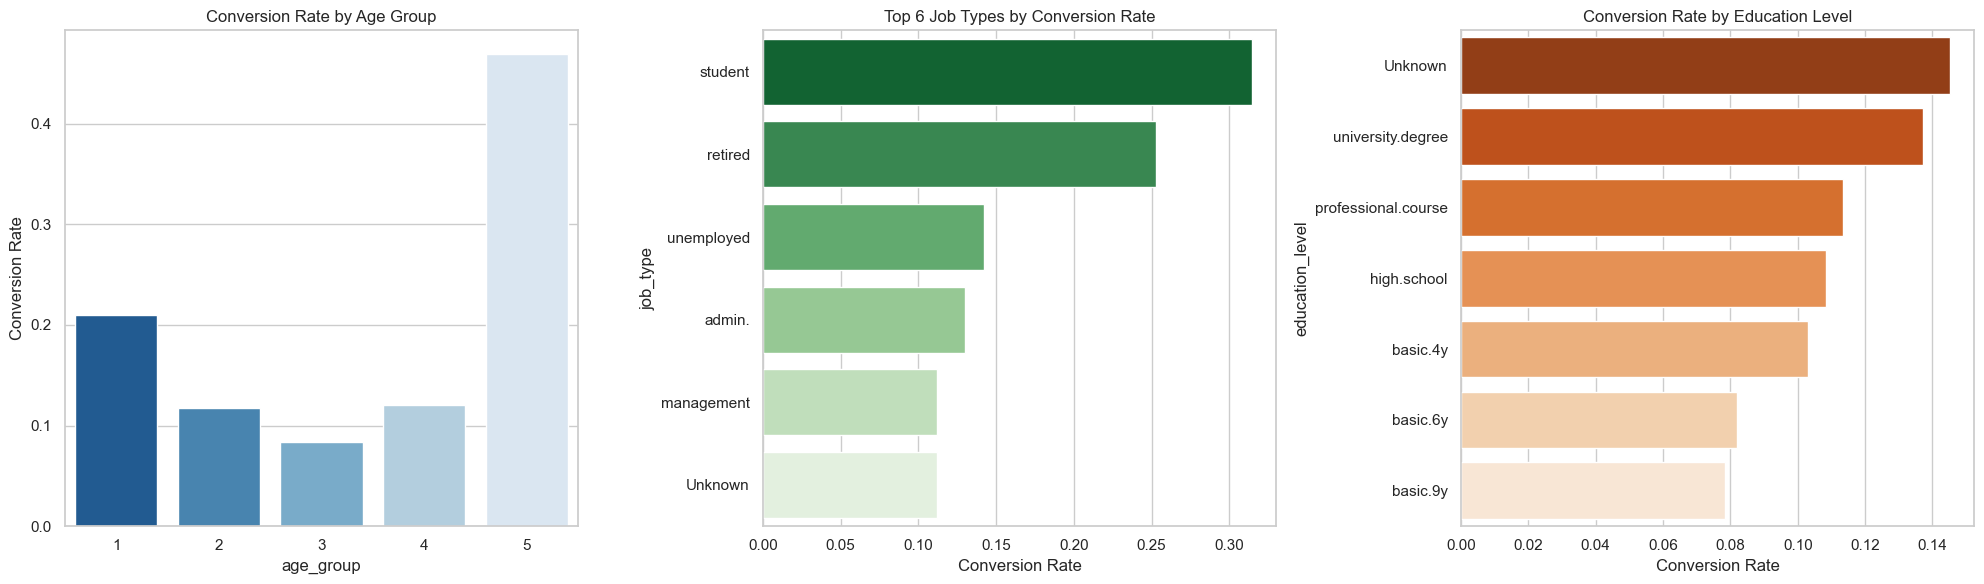

In [5]:
if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Conversion by Age Group
    age_conv = df.groupby('age_group', observed=True)['subscription_flag'].mean().sort_index()
    sns.barplot(x=age_conv.index, y=age_conv.values, ax=axes[0], palette='Blues_r')
    axes[0].set_title('Conversion Rate by Age Group')
    axes[0].set_ylabel('Conversion Rate')
    
    # Conversion by Job Type (Top 6)
    job_conv = df.groupby('job_type', observed=True)['subscription_flag'].mean().sort_values(ascending=False).head(6)
    sns.barplot(x=job_conv.values, y=job_conv.index, ax=axes[1], palette='Greens_r')
    axes[1].set_title('Top 6 Job Types by Conversion Rate')
    axes[1].set_xlabel('Conversion Rate')
    
    # Conversion by Education
    edu_conv = df.groupby('education_level', observed=True)['subscription_flag'].mean().sort_values(ascending=False)
    sns.barplot(x=edu_conv.values, y=edu_conv.index, ax=axes[2], palette='Oranges_r')
    axes[2].set_title('Conversion Rate by Education Level')
    axes[2].set_xlabel('Conversion Rate')
    
    plt.tight_layout()
    plt.show()

👉 **Insights:**
- **Age:** The youngest (Group 1) and oldest (Group 5) demographics have the highest conversion rates.
- **Job:** Students and retired individuals convert at a significantly higher rate.
- **Education:** Higher education (University Degree) slightly outperforms lower education levels.

## 3️⃣ TARGET VS FEATURE (Campaign Effectiveness - Dashboard 2)

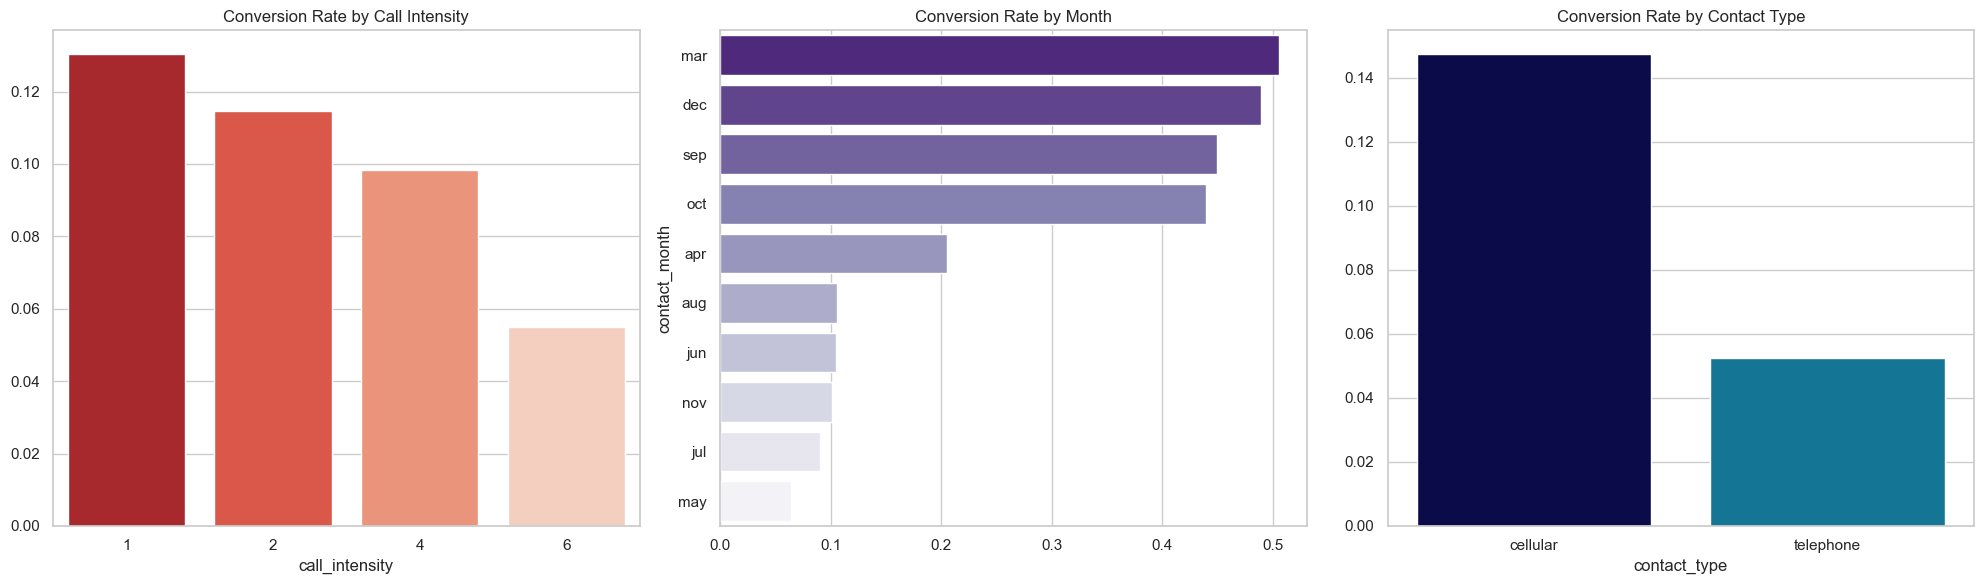

In [6]:
if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Conversion by Call Intensity
    call_conv = df.groupby('call_intensity', observed=True)['subscription_flag'].mean().sort_index()
    sns.barplot(x=call_conv.index, y=call_conv.values, ax=axes[0], palette='Reds_r')
    axes[0].set_title('Conversion Rate by Call Intensity')
    
    # Conversion by Contact Month
    month_conv = df.groupby('contact_month', observed=True)['subscription_flag'].mean().sort_values(ascending=False)
    sns.barplot(x=month_conv.values, y=month_conv.index, ax=axes[1], palette='Purples_r')
    axes[1].set_title('Conversion Rate by Month')
    
    # Conversion by Contact Type
    type_conv = df.groupby('contact_type', observed=True)['subscription_flag'].mean().sort_values(ascending=False)
    sns.barplot(x=type_conv.index, y=type_conv.values, ax=axes[2], palette='ocean')
    axes[2].set_title('Conversion Rate by Contact Type')
    
    plt.tight_layout()
    plt.show()

👉 **Insights:**
- **Intensity:** 1 call is optimal. The more you call, the lower the conversion probability.
- **Seasonality:** March, December, and September have the highest conversion rates, despite May having the most raw volume.
- **Contact Type:** Cellular networks drastically outperform landline telephones.

## 3️⃣ TARGET VS FEATURE (Interaction History - Dashboard 3)

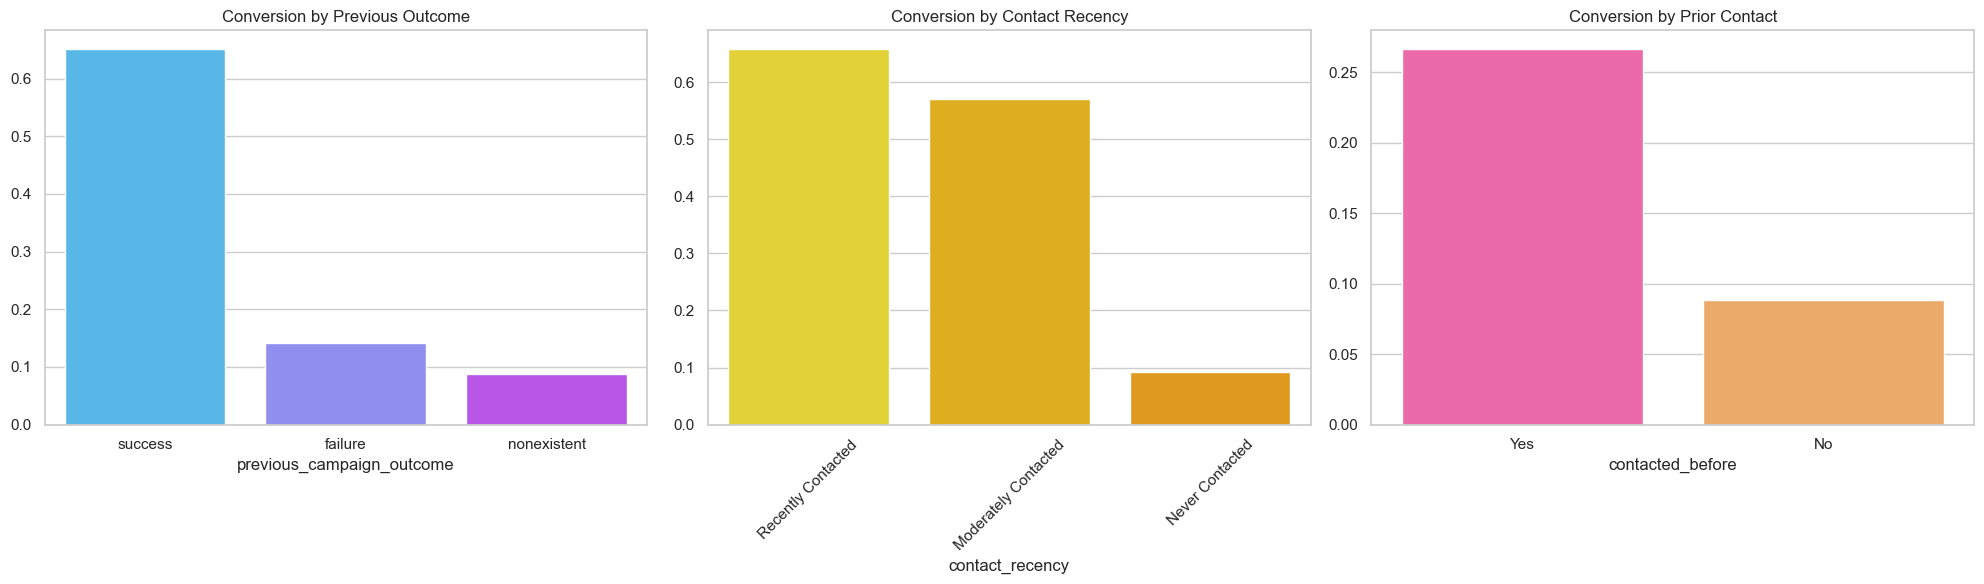

In [7]:
if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Previous Campaign Outcome
    prev_conv = df.groupby('previous_campaign_outcome', observed=True)['subscription_flag'].mean().sort_values(ascending=False)
    sns.barplot(x=prev_conv.index, y=prev_conv.values, ax=axes[0], palette='cool')
    axes[0].set_title('Conversion by Previous Outcome')
    
    # Contact Recency
    recency_conv = df.groupby('contact_recency', observed=True)['subscription_flag'].mean().sort_values(ascending=False)
    sns.barplot(x=recency_conv.index, y=recency_conv.values, ax=axes[1], palette='Wistia')
    axes[1].set_title('Conversion by Contact Recency')
    axes[1].tick_params(axis='x', rotation=45)
    
    # Contacted Before
    before_conv = df.groupby('contacted_before', observed=True)['subscription_flag'].mean().sort_values(ascending=False)
    sns.barplot(x=before_conv.index, y=before_conv.values, ax=axes[2], palette='spring')
    axes[2].set_title('Conversion by Prior Contact')
    
    plt.tight_layout()
    plt.show()

👉 **Insights:**
- **Previous Outcome:** If the customer successfully subscribed in a previous campaign, they have a massive ~65% chance of subscribing again.
- **Recency:** Reaching out to someone recently contacted yields vastly better results than calling cold ("Never Contacted").

## 3️⃣ TARGET VS FEATURE (Economic Factors - Dashboard 4)

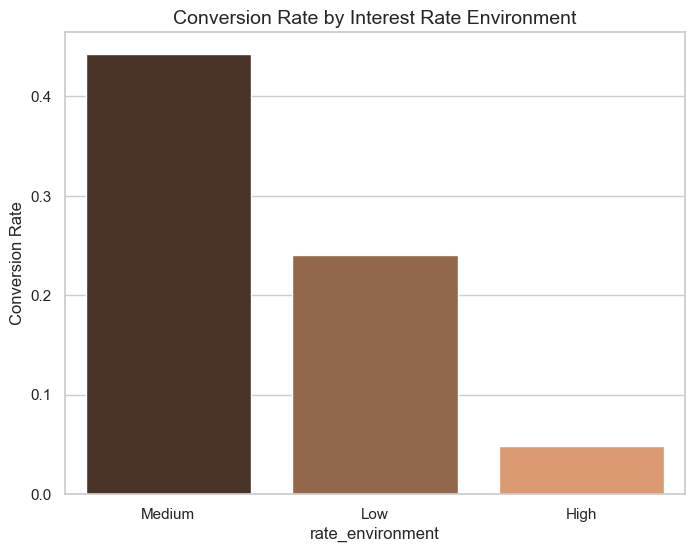

In [8]:
if not df.empty:
    plt.figure(figsize=(8, 6))
    rate_conv = df.groupby('rate_environment', observed=True)['subscription_flag'].mean().sort_values(ascending=False)
    sns.barplot(x=rate_conv.index, y=rate_conv.values, palette='copper')
    plt.title('Conversion Rate by Interest Rate Environment', fontsize=14)
    plt.ylabel('Conversion Rate')
    plt.show()

👉 **Insights:**
- **Economy:** A low interest rate environment heavily incentivizes customers to subscribe to the bank's offers.

## 4️⃣ CORRELATION (Heatmap)

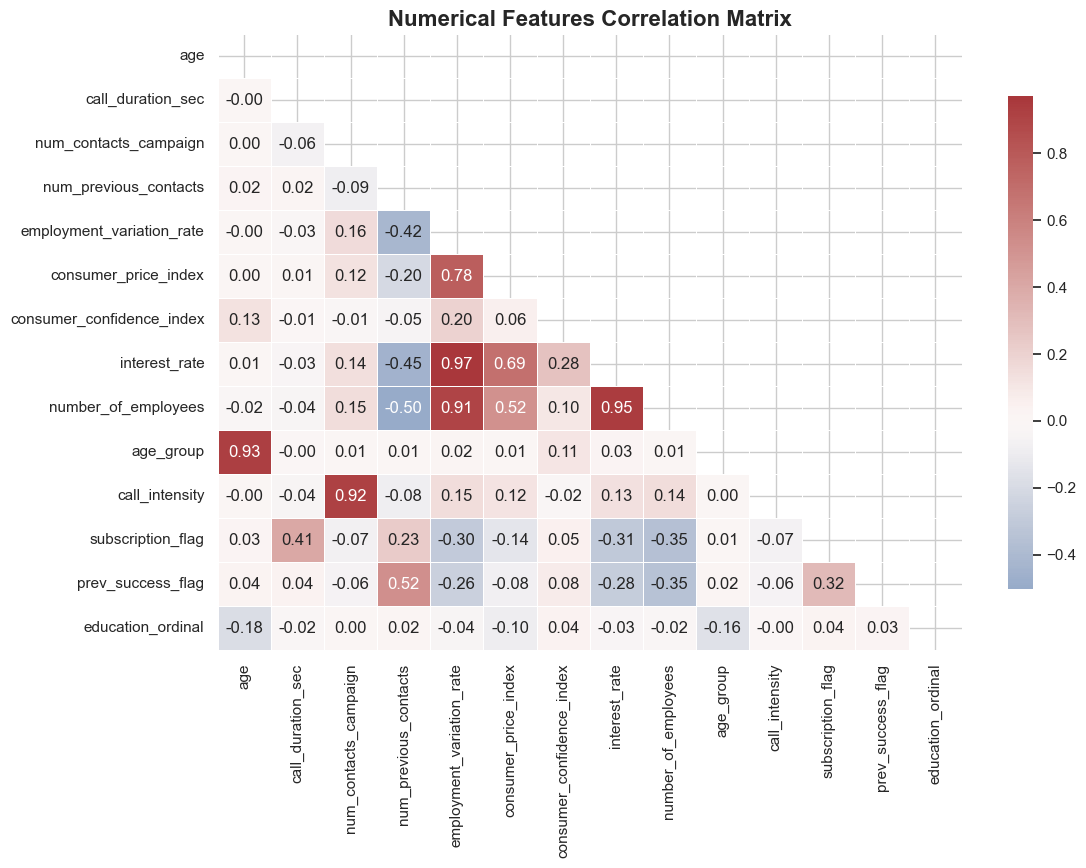

In [9]:
if not df.empty:
    plt.figure(figsize=(12, 8))
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Generate a mask for the upper triangle to make it cleaner
    mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
    
    sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title("Numerical Features Correlation Matrix", fontsize=16, fontweight='bold')
    plt.show()

👉 **Insights:**
- `call_duration_sec` has the strongest positive correlation with a successful subscription.
- Macroeconomic variables (`employment_variation_rate`, `consumer_price_index`, `interest_rate`, `number_of_employees`) are highly correlated with one another, representing the overall state of the economy.

## 5️⃣ OUTLIER CHECK

--- Campaign Contacts Summary ---


,num_contacts_campaign
count,41176.000000
mean,2.437075
std,2.030556
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,10.000000


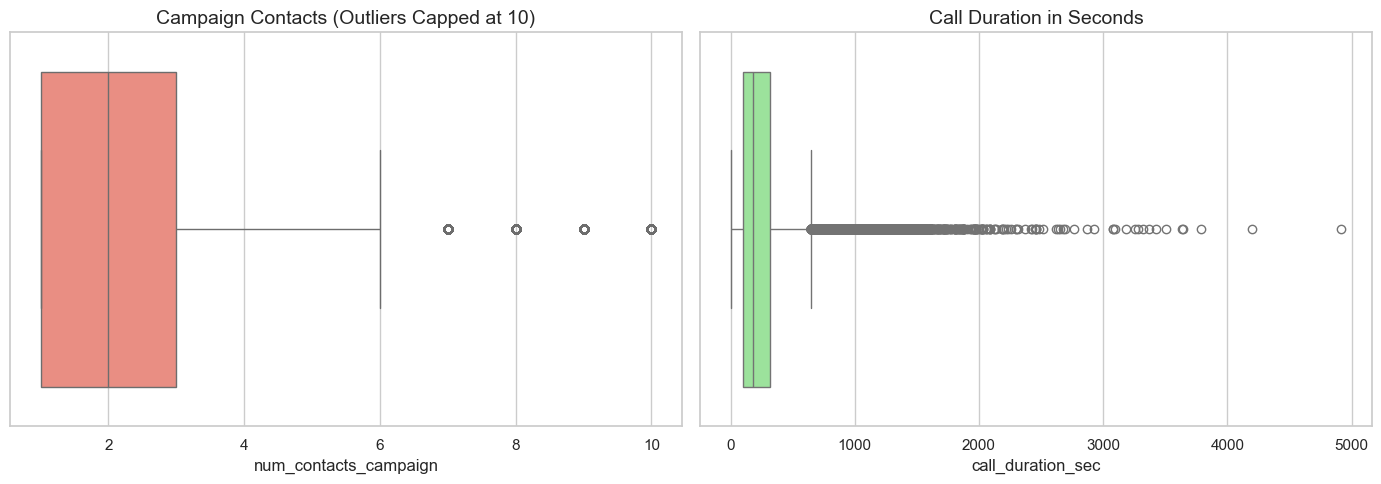

In [10]:
if not df.empty:
    print("--- Campaign Contacts Summary ---")
    display(df['num_contacts_campaign'].describe().to_frame())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.boxplot(x=df['num_contacts_campaign'], ax=axes[0], color='salmon')
    axes[0].set_title("Campaign Contacts (Outliers Capped at 10)", fontsize=14)
    
    sns.boxplot(x=df['call_duration_sec'], ax=axes[1], color='lightgreen')
    axes[1].set_title("Call Duration in Seconds", fontsize=14)
    
    plt.tight_layout()
    plt.show()

👉 **Insights:**
- **Contacts:** Extreme high-volume callers were successfully capped at 10 during data cleaning, ensuring our charts and aggregations aren't distorted.
- **Duration:** While `call_duration_sec` has many statistical outliers (calls lasting very long), these are genuine and highly predictive interactions, so they are retained.